## Dependencies

In [ ]:
!pip install transformers pillow torch torchvision

In [3]:
from PIL import Image
import requests
from io import BytesIO
from transformers import BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering, CLIPProcessor, CLIPModel
import torch

Example Image

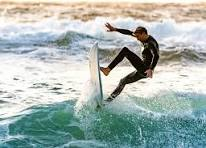

In [15]:
image = Image.open("/content/surf.jpeg")
image

## Image Captioning with BLIP
What is happening in the image?

In [16]:
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# The processor prepares the data so the model understands it (resize, normalize, ... the image)
inputs = processor(image, return_tensors = "pt") # "pt" = return pytorch tensor
# Run the processor's decoder to generate a description (this returns a tensor of token ids)
caption_ids = model.generate(**inputs, max_length=30)
# And now we just use a decoder to decode the token ids' meaning
caption = processor.decode(caption_ids[0], skip_special_tokens=True)
print(f"Caption: {caption}")

Caption: a man riding a wave on top of a surfboard


## Visual QA with BLIP-VQA

In [18]:
vqa_model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base")
vqa_processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")

q = "What color is the surfer's board?"
inputs = vqa_processor(image, q, return_tensors = "pt")
out = vqa_model.generate(**inputs, max_length = 30)
answer = vqa_processor.decode(out[0], skip_special_tokens = True)
print(f"Question: {q}\nAnswer: {answer}")

Question: What color is the surfer's board?
Answer: white


## Zero-shot Classification with CLIP
Classification given no prior examples

In [24]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# We are going to define some labels the model should classify from
labels = ["a person", "a wave", "a board", "the sea", "a truck"]

inputs = clip_processor(image, labels, return_tensors = "pt", padding=True)
with torch.no_grad():
  output = clip_model(**inputs)
  logits = output.logits_per_image[0] # logits = final scores (unnormalized) produced by the NN before an activation function
  probs = logits.softmax(dim=0)

for label, probability in zip(labels, probs):
  print(f"Label: {label} | Probability: {probability:.4f}")


Label: a person | Probability: 0.0007
Label: a wave | Probability: 0.3141
Label: a board | Probability: 0.6788
Label: the sea | Probability: 0.0064
Label: a truck | Probability: 0.0000
